# Import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Synthetic time series

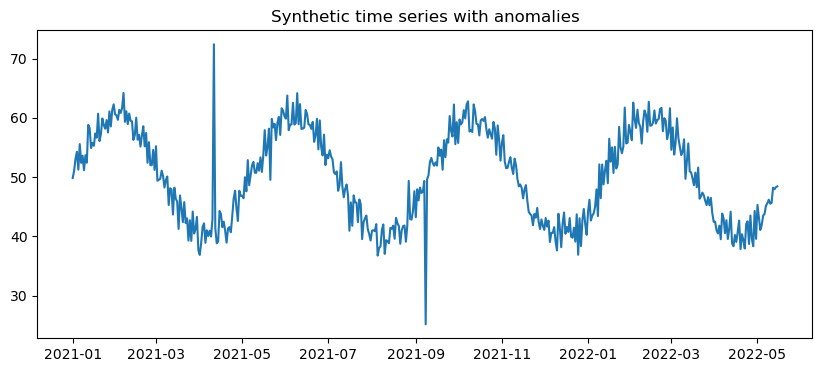

In [6]:
rng = pd.date_range('2021-01-01', periods=500, freq='D')
series = 50 + np.sin(np.arange(500)/20)*10 + np.random.normal(0,2,500)
# inject anomalies
series[100] += 30
series[250] -= 25


df = pd.DataFrame({'ds': rng, 'y': series})


plt.figure(figsize=(10,4))
plt.plot(df['ds'], df['y'])
plt.title('Synthetic time series with anomalies')
plt.show()

# Isolation Forest on rolling features

C:\Users\Neliswa\AppData\Local\Temp\ipykernel_14028\3097539897.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  'mean': df['y'].rolling(window).mean().fillna(method='bfill'),
C:\Users\Neliswa\AppData\Local\Temp\ipykernel_14028\3097539897.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  'std': df['y'].rolling(window).std().fillna(method='bfill')


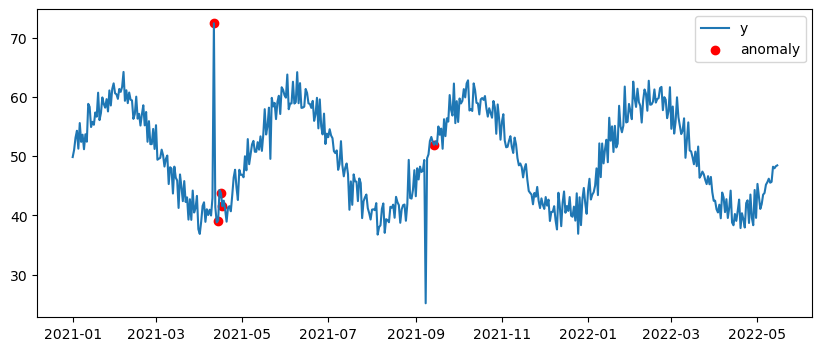

In [9]:
window = 7
X = pd.DataFrame({
'mean': df['y'].rolling(window).mean().fillna(method='bfill'),
'std': df['y'].rolling(window).std().fillna(method='bfill')
})


iso = IsolationForest(contamination=0.01, random_state=42)
iso.fit(X)
df['anomaly_score'] = iso.decision_function(X)
df['anomaly'] = iso.predict(X)


plt.figure(figsize=(10,4))
plt.plot(df['ds'], df['y'], label='y')
plt.scatter(df[df['anomaly']==-1]['ds'], df[df['anomaly']==-1]['y'], color='red', label='anomaly')
plt.legend()
plt.show()

# Export

In [12]:
df.to_csv('timeseries_anomalies.csv', index=False)
print('Exported timeseries_anomalies.csv')

Exported timeseries_anomalies.csv
